# Tari'ak Traffic Analysis, 03 — Visualizations and Insights

This notebook turns the segment-level clustering results from Notebook 02 into the final decision-support outputs: a map of candidate mobility bottlenecks, a ranked shortlist of the strongest candidates, and a view of when these slowdowns actually occur during the day.

I work from `segment_clusters.csv`, which covers 559 of the 14,289 total mapped road segments in the dataset, about 3.9% of the network. This is the subset with enough AM and PM peak-hour observations to support a reliable behavioral profile. Every result in this notebook inherits that same coverage limit, and I call it out again wherever the map or ranking is shown, since it's easy for that context to get lost once the focus shifts to visuals.

The notebook builds three outputs: a map of candidate bottleneck segments, so the pattern is visible geographically and not just as a table of IDs; a ranked list of the segments showing the strongest, most consistent slowdowns; and a view of when these slowdowns happen, to separate morning-specific, evening-specific, and all-day patterns.

As with the earlier notebooks, nothing here should be read as confirmed congestion or a causal claim. The clustering and ranking describe recurring patterns in historical, crowdsourced velocity data. They are a starting point for further investigation, not a verdict on any specific road.

In [ ]:
import pandas as pd
df = pd.read_csv('../data/processed/segment_clusters.csv')
print(df.shape)
df.head()

(559, 13)


,osm_id,cluster_id,cluster_label,dist_to_centroid,median_velocity,velocity_std,am_relative_slowdown,pm_relative_slowdown,am_slowdown_frequency,pm_slowdown_frequency,observation_count,active_days,zero_velocity_observation_count
0,way/108252090,2,Steady Moderate-Speed Flow,0.9499,39.8333,19.3927,-7.8740,0.2406,0.1250,0.7,3764,1349,4
1,way/108254454,0,High-Speed Free-Flow Corridors,1.4338,50.6044,21.1006,-8.4178,3.2508,0.3636,0.6,4585,1416,5
2,way/108284599,2,Steady Moderate-Speed Flow,1.1239,41.5080,19.8716,-9.1324,2.5711,0.3000,0.5,2737,573,60
3,way/108471452,4,Severe Morning-Peak Bottlenecks,1.3359,35.4330,11.8642,8.8087,-5.5989,1.0000,0.0,972,355,3
4,way/108755888,2,Steady Moderate-Speed Flow,1.8853,35.7950,15.3039,-5.8761,-0.2742,0.0000,0.0,862,406,2


I rank candidates using an expected slowdown score, computed as relative slowdown multiplied by slowdown frequency, separately for the AM and PM windows. A segment that is dramatically slower than its own baseline but only on one bad day should not rank above a segment that is moderately slower every single day, and this scoring reflects that. I clip negative slowdown values to zero before multiplying, since a segment running faster than its own baseline should not receive credit toward candidate severity. Each segment's overall score is the higher of its AM or PM expected slowdown, along with a flag for which peak drove it.

In [ ]:
import numpy as np

# Only positive relative_slowdown values represent an actual slowdown
# (negative means the segment was faster than its own baseline during that window)
df['am_expected_slowdown'] = df['am_relative_slowdown'].clip(lower=0) * df['am_slowdown_frequency']
df['pm_expected_slowdown'] = df['pm_relative_slowdown'].clip(lower=0) * df['pm_slowdown_frequency']

# Each segment's overall candidate score is its worse peak
df['candidate_severity'] = df[['am_expected_slowdown', 'pm_expected_slowdown']].max(axis=1)
df['primary_peak'] = np.where(
    df['am_expected_slowdown'] >= df['pm_expected_slowdown'], 'AM', 'PM'
)

df['confidence'] = np.where(df['active_days'] < 100, 'Lower', 'Standard')

top_candidates = df.sort_values('candidate_severity', ascending=False).head(20)

display_cols = [
    'osm_id', 'cluster_label', 'primary_peak', 'candidate_severity', 'confidence',
    'am_relative_slowdown', 'am_slowdown_frequency',
    'pm_relative_slowdown', 'pm_slowdown_frequency',
    'observation_count', 'active_days'
]

top_candidates[display_cols].round(2)

,osm_id,cluster_label,primary_peak,candidate_severity,confidence,am_relative_slowdown,am_slowdown_frequency,pm_relative_slowdown,pm_slowdown_frequency,observation_count,active_days
70,way/201126776,Severe Evening-Peak Bottlenecks,PM,55.11,Standard,-19.17,0.0,55.11,1.00,8566,1566
38,way/197464431,Severe Morning-Peak Bottlenecks,AM,50.14,Standard,50.14,1.0,-27.84,0.00,7468,1455
471,way/450610335,Severe Evening-Peak Bottlenecks,PM,41.06,Standard,-12.04,0.0,41.06,1.00,1168,447
112,way/23901698,Severe Morning-Peak Bottlenecks,AM,40.38,Standard,40.38,1.0,-9.16,0.26,7698,1475
251,way/266338800,Severe Morning-Peak Bottlenecks,AM,35.42,Standard,35.42,1.0,-8.14,0.00,1679,693
15,way/135202746,Severe Evening-Peak Bottlenecks,PM,31.99,Standard,-31.99,0.0,31.99,1.00,2503,1084
301,way/27000811,Severe Morning-Peak Bottlenecks,AM,30.38,Standard,30.38,1.0,-2.68,0.28,4044,1259
466,way/44583778,Severe Morning-Peak Bottlenecks,AM,30.14,Standard,30.14,1.0,-23.75,0.25,3470,1011
107,way/232349893,Severe Morning-Peak Bottlenecks,AM,28.25,Standard,28.25,1.0,-28.25,0.00,2583,1105
108,way/236021759,Severe Evening-Peak Bottlenecks,PM,26.28,Standard,-4.55,0.0,26.28,1.00,4557,1363


The ranking lines up cleanly with the cluster labels from Notebook 02. Every segment labeled a Severe Morning-Peak Bottleneck shows a slowdown frequency of 1.0 in the AM window and a negative or near-zero PM value, and the Evening-Peak segments show the mirror pattern. This is a useful check on the clustering itself: two different methods, distance-based grouping and this severity ranking, agree on which segments behave which way.

One candidate in this top 20, way/700100065, has only 21 active days of data compared to hundreds or thousands for its peers. It still passed the original observation and active-day thresholds from Notebook 01, so I keep it in the ranking rather than dropping it, but I flag it as lower confidence rather than treating it as equivalent evidence to the better-observed candidates around it.

## 2. Temporal Slowdown Profiles

While the candidate ranking quantifies peak severity, understanding when slowdowns recur across the day is necessary for practical planning. I query the `daily_segment_hour` table from SQLite for the 559 clustered segments and calculate the average relative slowdown for each hour from 00:00 through 23:00 across the five behavioral clusters.

A positive relative slowdown means that the observed velocity during that hour is lower than the segment's overall daily baseline.

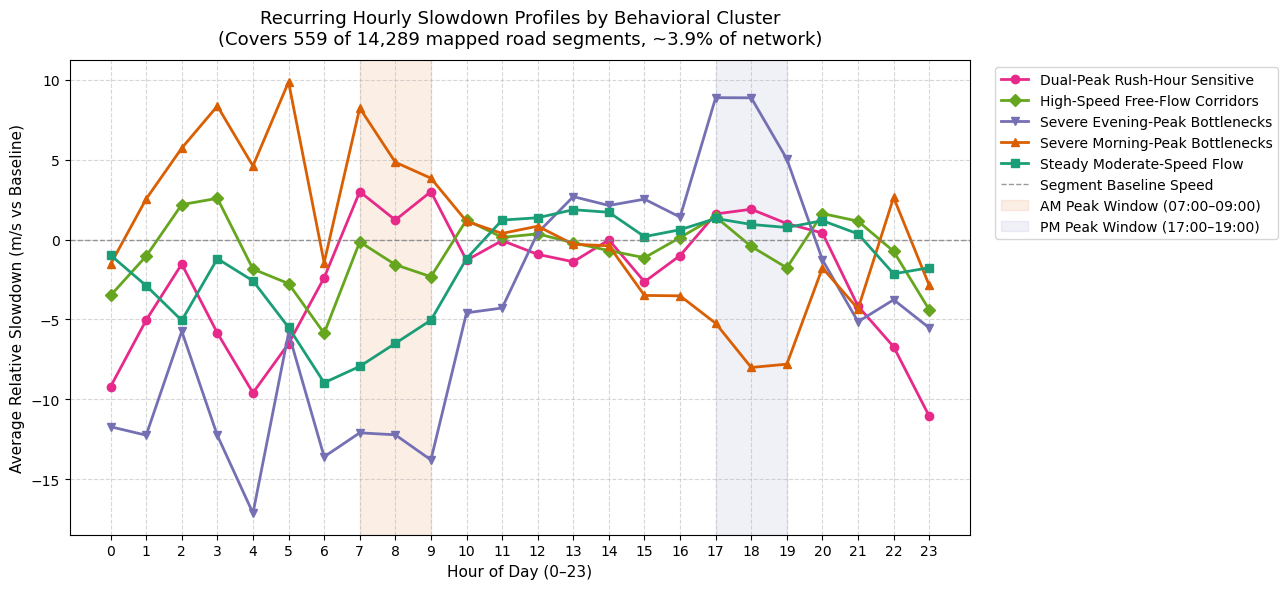

In [ ]:
import sqlite3
import matplotlib.pyplot as plt

# Query hourly velocities from SQLite for the clustered segments
conn = sqlite3.connect('../data/processed/traffic.db')
dsh = pd.read_sql('''
    SELECT osm_id, hour, daily_average_velocity
    FROM daily_segment_hour
''', conn)
conn.close()

# Merge with cluster labels and compute segment-level baseline and relative slowdowns
dsh = dsh.merge(df[['osm_id', 'cluster_label']], on='osm_id', how='inner')
seg_hourly = dsh.groupby(['osm_id', 'cluster_label', 'hour'])['daily_average_velocity'].mean().reset_index()
seg_baseline = dsh.groupby('osm_id')['daily_average_velocity'].mean().reset_index().rename(columns={'daily_average_velocity': 'baseline_velocity'})
seg_hourly = seg_hourly.merge(seg_baseline, on='osm_id')
seg_hourly['relative_slowdown'] = seg_hourly['baseline_velocity'] - seg_hourly['daily_average_velocity']

# Aggregate mean relative slowdown by cluster and hour
cluster_hourly = seg_hourly.groupby(['cluster_label', 'hour'])['relative_slowdown'].mean().reset_index()

# Plot temporal slowdown profiles
plt.figure(figsize=(13, 6))

colors = {
    'Severe Morning-Peak Bottlenecks': '#d95f02',
    'Severe Evening-Peak Bottlenecks': '#7570b3',
    'Dual-Peak Rush-Hour Sensitive': '#e7298a',
    'Steady Moderate-Speed Flow': '#1b9e77',
    'High-Speed Free-Flow Corridors': '#66a61e'
}

markers = {
    'Severe Morning-Peak Bottlenecks': '^',
    'Severe Evening-Peak Bottlenecks': 'v',
    'Dual-Peak Rush-Hour Sensitive': 'o',
    'Steady Moderate-Speed Flow': 's',
    'High-Speed Free-Flow Corridors': 'D'
}

for label, group in cluster_hourly.groupby('cluster_label'):
    plt.plot(
        group['hour'], group['relative_slowdown'],
        label=label,
        color=colors.get(label, '#333333'),
        marker=markers.get(label, 'o'),
        linewidth=2,
        markersize=6
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label='Segment Baseline Speed')
plt.axvspan(7, 9, color='#d95f02', alpha=0.10, label='AM Peak Window (07:00–09:00)')
plt.axvspan(17, 19, color='#7570b3', alpha=0.10, label='PM Peak Window (17:00–19:00)')

plt.title('Recurring Hourly Slowdown Profiles by Behavioral Cluster\n(Covers 559 of 14,289 mapped road segments, ~3.9% of network)', fontsize=13, pad=12)
plt.xlabel('Hour of Day (0–23)', fontsize=11)
plt.ylabel('Average Relative Slowdown (m/s vs Baseline)', fontsize=11)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

The hourly profiles visually confirm the timing patterns identified by the clustering:

1. The Severe Morning-Peak cluster shows a sharp positive slowdown peaking between 07:00 and 09:00, then runs mostly faster than its own baseline through the afternoon and evening, with a couple of brief exceptions around midday and late evening.
2. The Severe Evening-Peak cluster runs faster than its own baseline across every morning hour, then collapses into a severe slowdown between 17:00 and 19:00.
3. The Dual-Peak cluster displays two distinct slowdown crests aligning with both commuting windows.
4. The High-Speed and Steady Moderate-Speed clusters show much smaller deviations from baseline than the bottleneck clusters throughout the day, without the sharp single-direction peaks seen in the other three groups.

This hourly breakdown shows that the clusters reflect distinct diurnal movement schedules rather than random variance.

## 3. Geographic Distribution of Candidate Bottlenecks

I map the candidate segments geographically by joining `segment_clusters.csv` with representative longitude and latitude coordinates aggregated from the raw observations in SQLite.

The map displays all 559 sufficiently observed segments in the background, categorized by behavioral cluster, while highlighting the top 20 candidate bottleneck segments by expected severity.

**Scope caveat:** This visualization covers 559 of 14,289 mapped segments (~3.9% of the road network). Areas without points reflect an absence of peak-hour crowdsourced data rather than verified free flow.

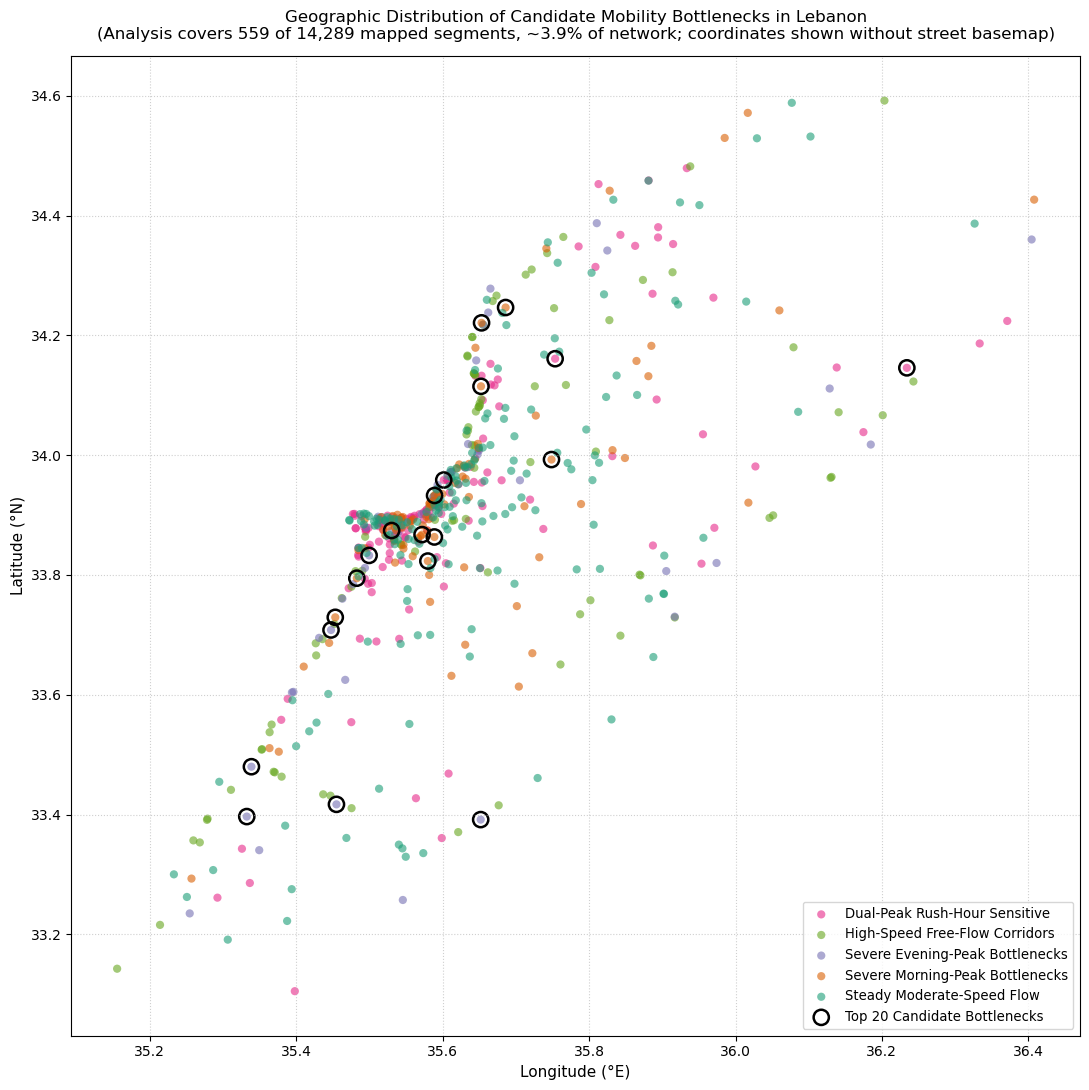

In [ ]:
# Extract representative coordinates for each segment from SQLite
conn = sqlite3.connect('../data/processed/traffic.db')
coords = pd.read_sql('''
    SELECT osm_id, AVG(longitude) AS lon, AVG(latitude) AS lat
    FROM traffic_observations
    GROUP BY osm_id
''', conn)
conn.close()

# Merge coordinates with the candidate dataset
geo_df = df.merge(coords, on='osm_id', how='inner')
geo_top20 = top_candidates.merge(coords, on='osm_id', how='inner')

fig, ax = plt.subplots(figsize=(11, 11))

# Plot all 559 qualified segments by cluster
for label, group in geo_df.groupby('cluster_label'):
    ax.scatter(
        group['lon'], group['lat'],
        c=colors.get(label, '#999999'),
        label=label,
        s=35,
        alpha=0.6,
        edgecolors='none'
    )

# Highlight top 20 candidate bottlenecks with prominent markers
ax.scatter(
    geo_top20['lon'], geo_top20['lat'],
    facecolors='none',
    edgecolors='black',
    s=120,
    linewidths=1.8,
    label='Top 20 Candidate Bottlenecks'
)

ax.set_title(
    'Geographic Distribution of Candidate Mobility Bottlenecks in Lebanon\n'
    '(Analysis covers 559 of 14,289 mapped segments, ~3.9% of network; coordinates shown without street basemap)',
    fontsize=12, pad=12
)
ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Latitude (°N)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', frameon=True, fontsize=9.5)

plt.tight_layout()
plt.show()

## 4. Visual Analysis & Decision-Support Conclusion

The map and ranking provide several practical insights for transportation planners:

1. **Spatial Concentration:** The top candidate bottlenecks are not evenly distributed across the network. Roughly two-thirds of the top 20 candidates sit tightly clustered in one geographic area consistent with the greater Beirut region, with a smaller number of outliers further south and one candidate near the Bekaa Valley. Identifying the specific roads or corridors involved is outside this dataset's scope, since it contains no road-name or road-classification fields, only coordinates.
2. **Peak Asymmetry:** The distinct morning versus evening slowdown profiles show that affected segments tend to be slow during one commuting window and comparatively fast during the other, rather than uniformly congested all day. This project has no inbound/outbound travel-direction data, so it cannot confirm whether this reflects directional commuting flow specifically, only that the timing of the slowdown differs sharply between morning and evening for these segments.
3. **Decision-Support Utility:** Rather than providing a definitive verdict on infrastructure needs, this screening allows municipalities and planning agencies to prioritize specific road segments for targeted traffic counts, localized sensor deployment, or signal timing optimization.
4. **Scope & Observational Discipline:** The analysis is strictly bounded by the 559 segments with complete peak-hour crowdsourced coverage (~3.9% of mapped streets). These results represent historical empirical slowdown signals, not live traffic feeds or causal determinations.